In [18]:
library("haven")
library("tidyverse")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.0     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [52]:
data <- read_dta("data/cen_ind_2021_pumf_v2.dta")

In [53]:
head(data)

ppsort,aboid,agegrp,ageimm,attsch,bfnmemb,bedrm,CFInc,CFInc_AT,cfstat,⋯,WT8,WT9,WT10,WT11,WT12,WT13,WT14,WT15,WT16,rand
<dbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,6,13,7,1,0,4,30,27,2,⋯,22.90113,22.90113,249.27876,22.90113,22.90113,22.90113,22.90113,22.90113,22.90113,2.025588
22,6,10,99,1,0,5,30,28,4,⋯,22.89284,22.89284,22.89284,249.18847,22.89284,22.89284,22.89284,22.89284,22.89284,2.436316
101,6,19,99,1,0,4,23,22,2,⋯,22.90134,22.90134,22.90134,22.90134,22.90134,22.90134,249.28105,22.90134,22.90134,2.080849
192,6,13,99,1,0,5,1,1,2,⋯,22.89284,22.89284,22.89284,22.89284,22.89284,22.89284,22.89284,22.89284,249.18847,2.794861
260,6,15,99,1,0,3,31,29,2,⋯,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,2.121870
264,6,1,99,9,0,2,12,12,4,⋯,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,249.19883,22.89379,2.164610


In [54]:
head(data$agegrp)

<labelled<double>[6]>: Age
[1] 13 10 19 13 15  1

Labels:
 value             label
     1      0 to 4 years
     2      5 to 6 years
     3      7 to 9 years
     4    10 to 11 years
     5    12 to 14 years
     6    15 to 17 years
     7    18 to 19 years
     8    20 to 24 years
     9    25 to 29 years
    10    30 to 34 years
    11    35 to 39 years
    12    40 to 44 years
    13    45 to 49 years
    14    50 to 54 years
    15    55 to 59 years
    16    60 to 64 years
    17    65 to 69 years
    18    70 to 74 years
    19    75 to 79 years
    20    80 to 84 years
    21 85 years and over
    88     Not available

In [56]:
data1 <- data |>
    mutate(agegrp = as.numeric(agegrp)) |>
    filter(agegrp>=17 & agegrp!=88)

head(data1)

ppsort,aboid,agegrp,ageimm,attsch,bfnmemb,bedrm,CFInc,CFInc_AT,cfstat,⋯,WT8,WT9,WT10,WT11,WT12,WT13,WT14,WT15,WT16,rand
<dbl>,<dbl+lbl>,<dbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
101,6,19,99,1,0,4,23,22,2,⋯,22.90134,22.90134,22.90134,22.90134,22.90134,22.90134,249.28105,22.90134,22.90134,2.080849
729,6,19,4,1,0,1,9,9,6,⋯,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,2.151134
977,6,17,1,1,0,5,11,10,7,⋯,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,249.19883,22.89379,22.89379,2.006523
2362,6,17,99,1,0,2,9,9,7,⋯,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,2.596228
2554,6,17,99,1,0,2,30,26,6,⋯,22.90134,22.90134,22.90134,22.90134,22.90134,22.90134,22.90134,22.90134,22.90134,2.195349
2562,6,18,99,1,0,4,25,22,1,⋯,22.88229,22.88229,22.88229,22.88229,22.88229,22.88229,22.88229,22.88229,22.88229,2.218869


In [50]:
(data1$oasgi)

[1] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
    [9] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
   [17] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
   [25] 99999999 99999999 99999999 99999999 88888888 99999999 99999999 99999999
   [33] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
   [41] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
   [49] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
   [57] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
   [65] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
   [73] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
   [81] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
   [89] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
   [97] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [105] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [113] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [121] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [129] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [137] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [145] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [153] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [161] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [169] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [177] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [185] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [193] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [201] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [209] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [217] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [225] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [233] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [241] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [249] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [257] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [265] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [273] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [281] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [289] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [297] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [305] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [313] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [321] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [329] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [337] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [345] 99999999 99999999 99999999 99999999 99999999     7300 99999999 99999999
  [353] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [361] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [369] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [377] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [385] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [393] 99999999 99999999 99999999 99999999 99999999 99999999 99999999 99999999
  [4

In [57]:
data3<-data1 |>
    filter(oasgi!=99999999)
head(data3)

ppsort,aboid,agegrp,ageimm,attsch,bfnmemb,bedrm,CFInc,CFInc_AT,cfstat,⋯,WT8,WT9,WT10,WT11,WT12,WT13,WT14,WT15,WT16,rand
<dbl>,<dbl+lbl>,<dbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
101,6,19,99,1,0,4,23,22,2,⋯,22.90134,22.90134,22.90134,22.90134,22.90134,22.90134,249.28105,22.90134,22.90134,2.080849
729,6,19,4,1,0,1,9,9,6,⋯,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,2.151134
977,6,17,1,1,0,5,11,10,7,⋯,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,249.19883,22.89379,22.89379,2.006523
2362,6,17,99,1,0,2,9,9,7,⋯,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,2.596228
2562,6,18,99,1,0,4,25,22,1,⋯,22.88229,22.88229,22.88229,22.88229,22.88229,22.88229,22.88229,22.88229,22.88229,2.218869
2596,6,17,99,1,0,3,25,23,2,⋯,22.91207,22.91207,22.91207,22.91207,22.91207,22.91207,22.91207,22.91207,22.91207,2.521437


In [58]:
data2 <- data1 |>
    filter(oasgi==99999999 | cqppb == 99999999) |>
    select(oasgi, cqppb, ageimm, Citizen, CitOth, lfact)

head(data2)

oasgi,cqppb,ageimm,Citizen,CitOth,lfact
<dbl>,<dbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>
18800,99999999,4,2,15,14
99999999,12300,99,1,15,2
99999999,2300,5,2,88,13
99999999,16100,99,1,15,13
99999999,4700,99,1,15,13
99999999,99999999,9,3,7,13


common trend in cpp => control cpp, study oas

subset 

In [67]:
data4 <- data |>
    mutate(agegrp = as.numeric(agegrp)) |>
    mutate(treat=ifelse(agegrp>=17 & agegrp!=88, 1,0))

head(data4)

ppsort,aboid,agegrp,ageimm,attsch,bfnmemb,bedrm,CFInc,CFInc_AT,cfstat,⋯,WT9,WT10,WT11,WT12,WT13,WT14,WT15,WT16,rand,treat
<dbl>,<dbl+lbl>,<dbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,<dbl+lbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,6,13,7,1,0,4,30,27,2,⋯,22.90113,249.27876,22.90113,22.90113,22.90113,22.90113,22.90113,22.90113,2.025588,0
22,6,10,99,1,0,5,30,28,4,⋯,22.89284,22.89284,249.18847,22.89284,22.89284,22.89284,22.89284,22.89284,2.436316,0
101,6,19,99,1,0,4,23,22,2,⋯,22.90134,22.90134,22.90134,22.90134,22.90134,249.28105,22.90134,22.90134,2.080849,1
192,6,13,99,1,0,5,1,1,2,⋯,22.89284,22.89284,22.89284,22.89284,22.89284,22.89284,22.89284,249.18847,2.794861,0
260,6,15,99,1,0,3,31,29,2,⋯,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,2.121870,0
264,6,1,99,9,0,2,12,12,4,⋯,22.89379,22.89379,22.89379,22.89379,22.89379,22.89379,249.19883,22.89379,2.164610,0


In [63]:
head(data$lfact)

<labelled<double>[6]>: Labour: Labour force status - Detailed
[1] 88  1 13  1  1 99

Labels:
 value                                                     label
     2                       Employed - Absent in reference week
     3     Unemployed - Temporary layoff - Did not look for work
     4 Unemployed - Temporary layoff - Looked for full-time work
     5 Unemployed - Temporary layoff - Looked for part-time work
     6              Unemployed - New job - Did not look for work
     7          Unemployed - New job - Looked for full-time work
     8          Unemployed - New job - Looked for part-time work
     9                    Unemployed - Looked for full-time work
    10                    Unemployed - Looked for part-time work
    11             Not in the labour force - Last worked in 2021
    12             Not in the labour force - Last worked in 2020
    13         Not in the labour force - Last worked before 2020
    14                    Not in the labour force - Never work

In [83]:
data5 <- data4 |>
    mutate(lfact = as.numeric(lfact)) |>
    filter(lfact<=13) |>
    mutate(outcome=ifelse(lfact>=11 & lfact<=13, 1,0)) |>
    group_by(agegrp) |>
    summarise(prop_retire=mean(outcome)) |>
    filter(agegrp>=15 & agegrp<=21)

head(data5)
tail(data5,10)

agegrp,prop_retire
<dbl>,<dbl>
15,0.2265579
16,0.4018987
17,0.6882022
18,0.8407163
19,0.9189580
20,0.9676550


agegrp,prop_retire
<dbl>,<dbl>
15,0.2265579
16,0.4018987
17,0.6882022
18,0.8407163
19,0.9189580
20,0.9676550
21,0.9703947


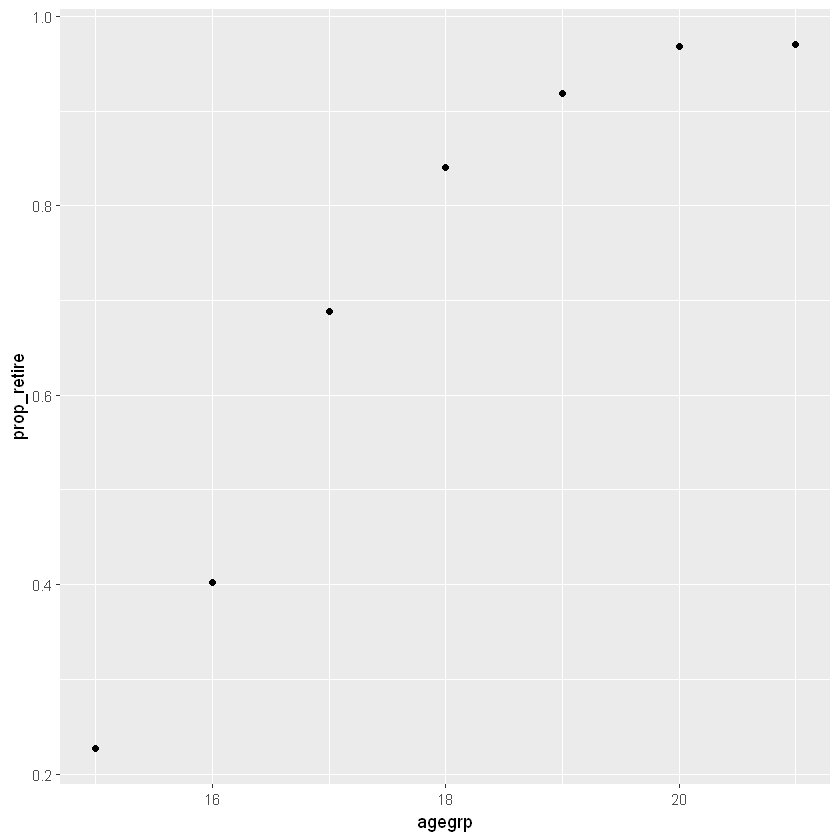

In [84]:
library(ggplot2)

ggplot(data=data5, aes(x=agegrp,y=prop_retire))+
    geom_point()

In [82]:
    mutate(treat=ifelse(agegrp>=15 & agegrp<=19, 1,0))


ERROR: Error in eval(expr, envir, enclos): object 'agegrp' not found
